Problem 1 - (a)

   eruptions  waiting
0      3.600       79
1      1.800       54
2      3.333       74
3      2.283       62
4      4.533       85


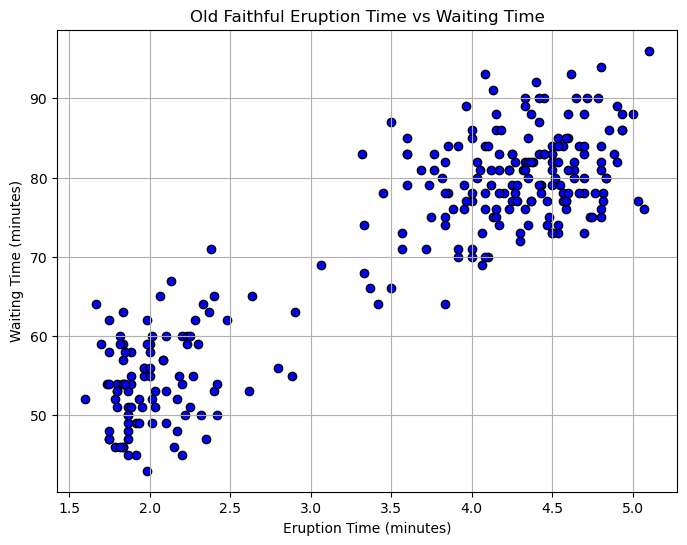

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv(r"C:\Users\VAGBHAT\Downloads\faithful.csv")

print(data.head())

plt.figure(figsize=(8, 6))
plt.scatter(data['eruptions'], data['waiting'], color='blue', edgecolor='black')
plt.title('Old Faithful Eruption Time vs Waiting Time')
plt.xlabel('Eruption Time (minutes)')
plt.ylabel('Waiting Time (minutes)')
plt.grid(True)
plt.show()


Problem 1 - (b)

Based on the scatter plot of eruption time versus waiting time, there are 2 clear clusters formed.

Cluster 1 : It has shorter eruptions  around 2 minutes or less and a shorter waiting time around 50–70 minutes.

Cluster 2 : It has longer eruptions around 4–5 minutes and a longer waiting time (around 75–90 minutes).

There is a visible gap between these two groups, suggesting two natural clusters.


Problem 1 - (c)

Hierarchical Clustering Algorithm is a process of building a hierarchy of clusters.
There are two main types of hierarchical clustering algorithms. They are:
1.) Agglomerative Hierarchical Clustering:
This follows bottom-up approach and it is most commonly used hierarchical clustering algorithm.
In this type we start with each data point as its own cluster.
Then iteratively merge the closest clusters until all the data points from one single cluster or until a desired no of clusters is reached.
The merging decisions are done using a linkage criteria. 
Dendrogram is used to visualize.

2). Divisive Hierarchical Clustering:
This type follows a top-down approach and it is less commonly used.
In this type we start with all data points in one big cluster.
Split the cluster into two sub clusters using any method like k-means.
Then recursively split the cluster into smaller clusters based on the largest internal dissimilarity.
Then we continue splitting until each data point is its own cluster or until a stopping condition is met.
This is represented as a binary tree called dendrogram.

Would hierarchical clustering be appropriate for this dataset?

Yes, hierarchical clustering would be appropriate for the Old Faithful dataset. Since, the scatter plot displays two clear and well-separated groups of points. Hierarchical clustering also provides a dendrogram. Hierarchical clustering is especially good when natural groupings exist and when you want to visualize the structure of data through a dendrogram. Thus, it would work well here to find the two main clusters we observed.

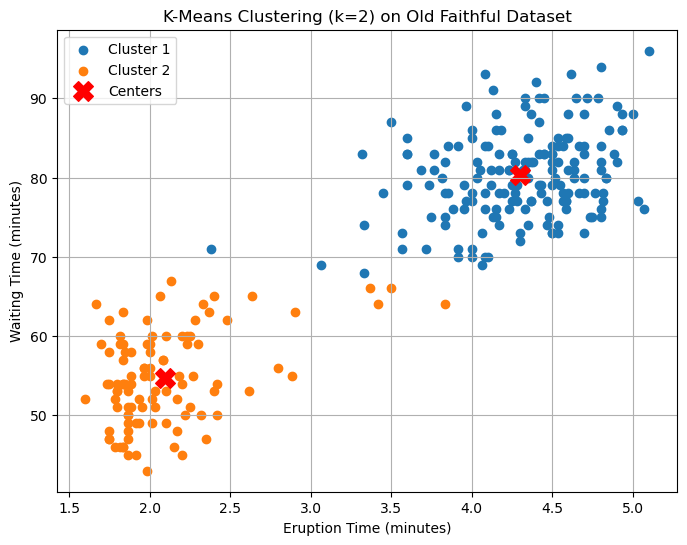

In [24]:
#Problem 2 - (a)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv(r"C:\Users\VAGBHAT\Downloads\faithful.csv")
X = data[['eruptions', 'waiting']].values

def kmeans(X, k=2, max_iters=100):
    np.random.seed(42)
    random_indices = np.random.choice(len(X), size=k, replace=False)
    centers = X[random_indices]
    
    for iteration in range(max_iters):
        distances = np.linalg.norm(X[:, np.newaxis] - centers, axis=2)
        labels = np.argmin(distances, axis=1)
        new_centers = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        if np.allclose(centers, new_centers):
            break
        centers = new_centers
    return centers, labels
centers, labels = kmeans(X, k=2)

#Problem 2 - (b)
plt.figure(figsize=(8, 6))
for i in range(2):
    plt.scatter(X[labels == i, 0], X[labels == i, 1], label=f'Cluster {i+1}')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centers')
plt.title('K-Means Clustering (k=2) on Old Faithful Dataset')
plt.xlabel('Eruption Time (minutes)')
plt.ylabel('Waiting Time (minutes)')
plt.legend()
plt.grid(True)
plt.show()


Problem 2 - (c)

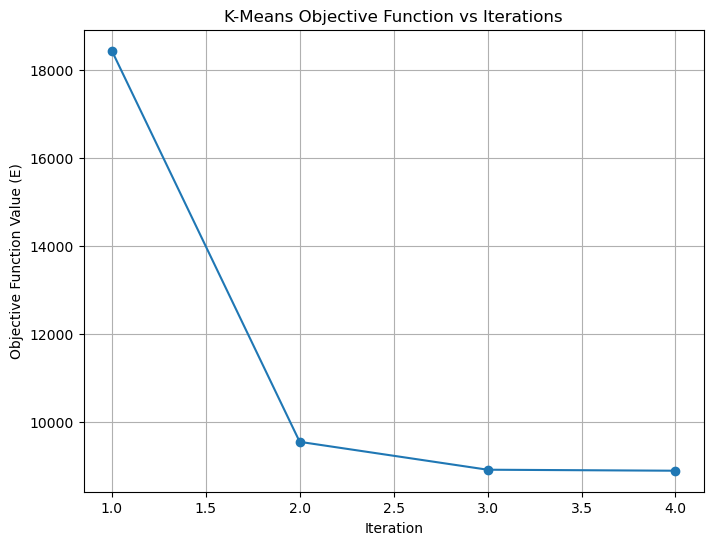

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv(r"C:\Users\VAGBHAT\Downloads\faithful.csv")
X = data[['eruptions', 'waiting']].values
def kmeans_with_objective(X, k=2, max_iters=100):
    np.random.seed(42)
    random_indices = np.random.choice(len(X), size=k, replace=False)
    centers = X[random_indices]
    
    objective_values = []  # To store E at each iteration

    for iteration in range(max_iters):
        distances = np.linalg.norm(X[:, np.newaxis] - centers, axis=2)
        labels = np.argmin(distances, axis=1)
        new_centers = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        E = 0
        for i in range(k):
            cluster_points = X[labels == i]
            E += np.sum((cluster_points - centers[i])**2)
        objective_values.append(E)
        if np.allclose(centers, new_centers):
            break
        centers = new_centers
        
    return centers, labels, objective_values
centers, labels, objective_values = kmeans_with_objective(X, k=2)
plt.figure(figsize=(8,6))
plt.plot(range(1, len(objective_values)+1), objective_values, marker='o')
plt.title('K-Means Objective Function vs Iterations')
plt.xlabel('Iteration')
plt.ylabel('Objective Function Value (E)')
plt.grid(True)
plt.show()


Problem 2 - (d)

Yes, the K-Means method managed to find the two clusters that I identified earlier in Problem 1.
The clustering separated the data into two clear groups:
Lower-left group with shorter eruption times and shorter waiting times,
Another is the upper-right group with longer eruption times and longer waiting times.

I have also logically positioned the cluster centers within the middle of each group.
I have set a fixed random seed which made the initialization stable, and because of that I did not have to run the method multiple times.
However, if random initialization were different, running K-Means multiple times with different starting points would help in avoiding bad local minima.

Overall, the clustering aligned very well with the visual clusters seen in the scatter plot.